# thetaFlow 2-D Spatial Simulation Demo

This notebook demonstrates how to use the 2-D spatial simulation capabilities of `thetaFlow`. 
The 2-D module couples 1-D soil columns with lateral surface runoff and subsurface throughflow routing.

In [7]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulate_spatial import ( 
    run_spatial_simulation, 
    SpatialConfig, 
    _generate_synthetic_dem, 
    load_spatial_config
)
from spatial_utils import RasterMeta
from spatial_visualise import animate_spatial_results

## 1. Synthetic Data Generation

We start by generating a synthetic Digital Elevation Model (DEM) and associated maps for land-cover and soil types.

In [ ]:
N = 20
cell_size_m = 50.0
dem = _generate_synthetic_dem(nrows=N, ncols=N, cell_size=cell_size_m)

# Uniform land cover (all grass). Soil code 2 = "loam" in soil_types_example.json
# (Ks ~ 10 mm/h) rather than the default code 1 = "sandy loam" (Ks ~ 44 mm/h):
# sandy loam's infiltration capacity never drops below the 12 mm/h rainfall
# pulses below, so no surface runoff (and hence no 2-D routing) would ever
# occur -- loam lets the rain exceed infiltration capacity and generate
# visible overland flow.
landcover_codes = np.ones((N, N), dtype=np.int32)
soil_codes = np.full((N, N), 2, dtype=np.int32)

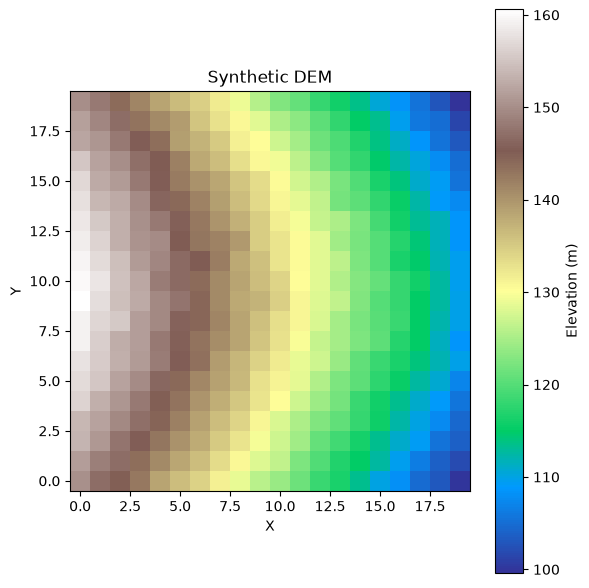

In [8]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(dem, cmap='terrain', origin='lower')
fig.colorbar(im, ax=ax, label='Elevation (m)')
ax.set_title('Synthetic DEM')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.tight_layout()
# plt.show()


## 2. Forcing Setup

Define a uniform forcing sequence (rainfall and potential evapotranspiration).

In [ ]:
# Create a simple forcing DataFrame
noHours = 5 * 24
dates = pd.date_range('2023-01-01', periods=noHours, freq='h')
forcing_df = pd.DataFrame({
    'datetime': dates,
    'rainfall_mm_h': [12.0 if i % 12 == 0 else 0.0 for i in range(noHours)],
    'pet_mm_h': [0.1] * noHours
}).set_index('datetime')

print(forcing_df.head())

ax = forcing_df[['rainfall_mm_h', 'pet_mm_h']].plot(
    figsize=(10, 4),
    title='Forcing Time Series'
)
ax.set_xlabel('Datetime')
ax.set_ylabel('mm/h')
plt.tight_layout()
plt.show()

                     rainfall_mm_h  pet_mm_h
datetime                                    
2023-01-01 00:00:00           12.0       0.1
2023-01-01 01:00:00            0.0       0.1
2023-01-01 02:00:00            0.0       0.1
2023-01-01 03:00:00            0.0       0.1
2023-01-01 04:00:00            0.0       0.1


## 3. Configuration

Configure the simulation using `SpatialConfig`.

In [18]:
# Use the example config file or create one manually
config_path = Path('spatial_config_example.json')
if config_path.exists():
    cfg = load_spatial_config(config_path)
else:
    # Fallback manual config
    from simulate_spatial import ColumnConfig, SimulationConfig
    cfg = SpatialConfig(
        cell_size_m=50.0,
        column=ColumnConfig(nz=10, dz_m=0.1),
        simulation=SimulationConfig(initial_head_m=-1.0)
    )

print(f"Cell size: {cfg.cell_size_m} m")
print(f"Column depth: {cfg.column.nz * cfg.column.dz_m} m")

Cell size: 50.0 m
Column depth: 1.0 m


## 4. Running the Simulation

Now we run the spatial simulation.

In [ ]:
output_dir = Path('outputs_demo')
veg_json_path = Path('vegetation_types.json')
soil_types_json_path = Path('soil_types_example.json')

# Map landcover codes to vegetation names
code_to_veg_name = {1: 'grass'}

# Ensure the forcing dataframe includes the time-step column expected by the simulator.
forcing_df = forcing_df.copy()
forcing_df["dt_seconds"] = (
    forcing_df.index.to_series().diff().dt.total_seconds().fillna(3600.0).astype(float)
)
forcing_df.loc[forcing_df.index[0], "dt_seconds"] = 3600.0

run_spatial_simulation(
    dem=dem,
    landcover_codes=landcover_codes,
    soil_codes=soil_codes,
    veg_json_path=veg_json_path,
    soil_types_json_path=soil_types_json_path,
    code_to_veg_name=code_to_veg_name,
    forcing_uniform=forcing_df,
    forcing_gridded=None,
    cfg=cfg,
    output_dir=output_dir,
    n_workers=1
)

print("Simulation complete. Results saved to", output_dir)




Grid: 20 × 20 = 400 cells  |  cell size: 50.0 m
Starting simulation…
  Step    0 | dt=3600s | mean_θ=0.120 | max_depth=0.0000 m | wall=9.6s
  Step    1 | dt=3600s | mean_θ=0.120 | max_depth=0.0000 m | wall=3.8s
  Step    2 | dt=3600s | mean_θ=0.120 | max_depth=0.0000 m | wall=3.1s
  Step    3 | dt=3600s | mean_θ=0.120 | max_depth=0.0000 m | wall=3.1s
  Step    4 | dt=3600s | mean_θ=0.120 | max_depth=0.0000 m | wall=3.2s
  Step    5 | dt=3600s | mean_θ=0.120 | max_depth=0.0000 m | wall=3.6s
  Step    6 | dt=3600s | mean_θ=0.120 | max_depth=0.0000 m | wall=3.9s
  Step    7 | dt=3600s | mean_θ=0.120 | max_depth=0.0000 m | wall=3.0s
  Step    8 | dt=3600s | mean_θ=0.119 | max_depth=0.0000 m | wall=3.0s
  Step    9 | dt=3600s | mean_θ=0.119 | max_depth=0.0000 m | wall=3.0s
  Step   10 | dt=3600s | mean_θ=0.119 | max_depth=0.0000 m | wall=3.7s
  Step   11 | dt=3600s | mean_θ=0.119 | max_depth=0.0000 m | wall=4.2s
  Step   12 | dt=3600s | mean_θ=0.131 | max_depth=0.0000 m | wall=7.2s
  Step  

## 5. Visualization

Generate MP4 animations of the results.

Saved outputs_demo/soil_moisture.mp4
Saved outputs_demo/overland_flow.mp4
Saved outputs_demo/combined.mp4
Animations generated in outputs_demo


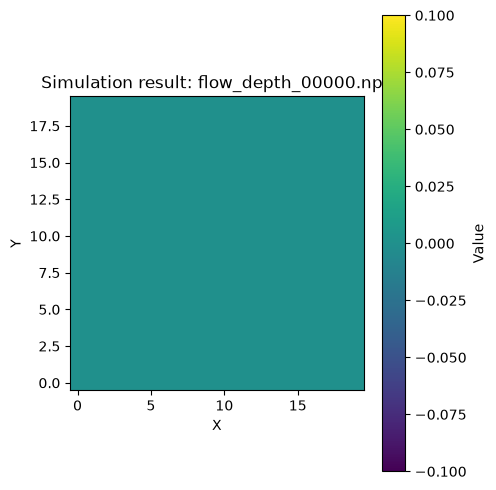

In [20]:
animate_spatial_results(
    output_dir=output_dir,
    dem=dem,
    cell_size_m=cfg.cell_size_m,
    n_steps=len(forcing_df)
)
# Quick summary plot of the saved simulation output arrays

result_files = sorted(output_dir.glob("*.npy"))
if result_files:
    plotted = False
    for p in result_files:
        try:
            arr = np.load(p)
        except Exception:
            continue

        plot_arr = None
        if arr.ndim == 2 and arr.shape == dem.shape:
            plot_arr = arr
            title = p.name
        elif arr.ndim == 3:
            if arr.shape[1:] == dem.shape:
                plot_arr = arr[-1]
                title = f"{p.name} (final step)"
            elif arr.shape[:-1] == dem.shape:
                plot_arr = arr[:, :, -1]
                title = f"{p.name} (final step)"
        if plot_arr is not None:
            fig2, ax2 = plt.subplots(figsize=(5, 5))
            im2 = ax2.imshow(plot_arr, cmap="viridis", origin="lower")
            fig2.colorbar(im2, ax=ax2, label="Value")
            ax2.set_title(f"Simulation result: {title}")
            ax2.set_xlabel("X")
            ax2.set_ylabel("Y")
            plt.tight_layout()
            plotted = True
            break

    if not plotted:
        print("No compatible 2D simulation arrays found in", output_dir)
        print("Available output files:", [p.name for p in result_files[:10]])
else:
    print("No .npy outputs found in", output_dir)
print("Animations generated in", output_dir)